# Time Series Preparation for TimeGAN

## Objective

Prepare the SGCC Electricity Theft Detection dataset for TimeGAN training.

### Steps
- Load the cleaned dataset
- Separate honest and theft users
- Remove non-time-series columns
- Handle missing values
- Normalize electricity consumption
- Convert into TimeGAN-compatible sequences
- Save processed sequences

In [3]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("../data/data set.csv")

print(df.shape)

df.head()

(42372, 1036)


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,CONS_NO,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,0387DD8A07E07FDA6271170F86AD9151,1
1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,01D6177B5D4FFE0CABA9EF17DAFC2B84,1
2,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,13.44,11.34,...,NaN,1.43,2.22,2.41,3.48,2.89,1.88,1.16,4B75AC4F2D8434CFF62DB64D0BB43103,1
3,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67,B32AC8CC6D5D805AC053557AB05F5343,1
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13,EDFC78B07BA2908B3395C4EB2304665E,1


In [5]:
honest = df[df["FLAG"] == 0].copy()

theft = df[df["FLAG"] == 1].copy()

honest_ts = honest.drop(columns=["CONS_NO", "FLAG"])

theft_ts = theft.drop(columns=["CONS_NO", "FLAG"])

print(honest_ts.shape)

print(theft_ts.shape)
print("Honest Missing :", honest_ts.isnull().sum().sum())

print("Theft Missing :", theft_ts.isnull().sum().sum())

(38757, 1034)
(3615, 1034)
Honest Missing : 10057255
Theft Missing : 1176273


Median Imputation

In [10]:
# Remove columns that are completely empty

all_nan_cols = honest_ts.columns[honest_ts.isnull().all()]

print("Columns removed:", len(all_nan_cols))

honest_ts = honest_ts.drop(columns=all_nan_cols)

theft_ts = theft_ts.drop(columns=all_nan_cols)

print(all_nan_cols)

Columns removed: 0
Index([], dtype='str')


In [9]:
imputer = SimpleImputer(strategy="median")

honest_ts = pd.DataFrame(
    imputer.fit_transform(honest_ts),
    columns=honest_ts.columns
)

theft_ts = pd.DataFrame(
    imputer.transform(theft_ts),
    columns=theft_ts.columns
)

print("Remaining Missing Values:")

print(honest_ts.isnull().sum().sum())

print(theft_ts.isnull().sum().sum())

Remaining Missing Values:
0
0


Normalize and Verify Range

In [11]:
scaler = MinMaxScaler()

honest_scaled = scaler.fit_transform(honest_ts)

theft_scaled = scaler.transform(theft_ts)

print("Honest")

print(honest_scaled.min(), honest_scaled.max())

print()

print("Theft")

print(theft_scaled.min(), theft_scaled.max())

Honest
0.0 1.0

Theft
0.0 459.24003923666845


Plot One Theft User

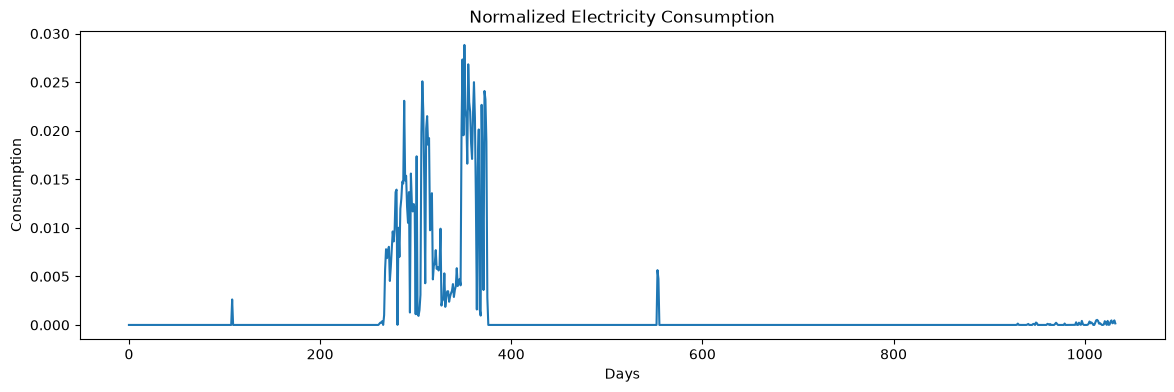

In [12]:
plt.figure(figsize=(14,4))

plt.plot(theft_scaled[0])

plt.title("Normalized Electricity Consumption")

plt.xlabel("Days")

plt.ylabel("Consumption")

plt.show()

Plot One Honest User

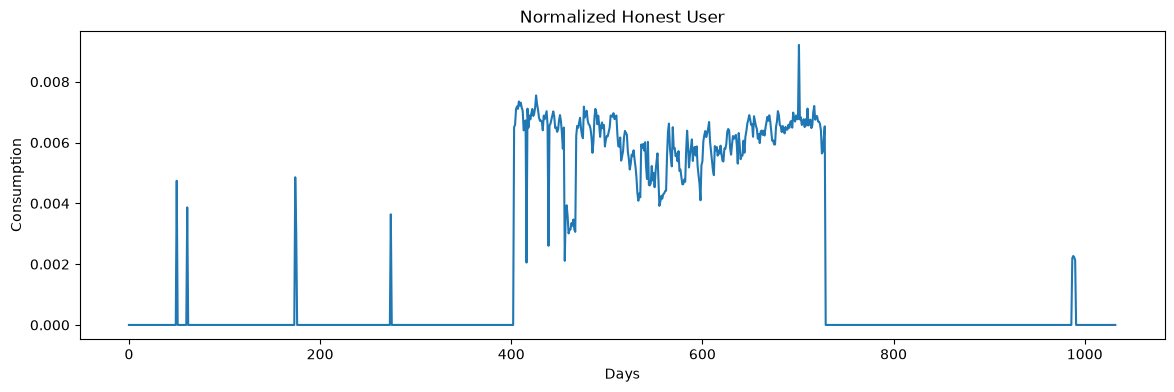

In [13]:
plt.figure(figsize=(14,4))

plt.plot(honest_scaled[0])

plt.title("Normalized Honest User")

plt.xlabel("Days")

plt.ylabel("Consumption")

plt.show()

Convert to TimeGAN Format

In [14]:
theft_sequences = theft_scaled.reshape(
    theft_scaled.shape[0],
    theft_scaled.shape[1],
    1
)

honest_sequences = honest_scaled.reshape(
    honest_scaled.shape[0],
    honest_scaled.shape[1],
    1
)

Check Shape

In [15]:
print("Theft Sequence Shape")

print(theft_sequences.shape)

print()

print("Honest Sequence Shape")

print(honest_sequences.shape)

Theft Sequence Shape
(3615, 1033, 1)

Honest Sequence Shape
(38757, 1033, 1)


In [16]:
np.save("../models/theft_sequences.npy", theft_sequences)

np.save("../models/honest_sequences.npy", honest_sequences)

joblib.dump(scaler, "../models/minmax_scaler.pkl")

print("TimeGAN input saved successfully!")

TimeGAN input saved successfully!


Summary

In [17]:
print("="*50)

print("Notebook 03 Completed")

print("="*50)

print("Theft Sequences :", theft_sequences.shape)

print("Honest Sequences :", honest_sequences.shape)

print("Scaler Saved")

print("="*50)

Notebook 03 Completed
Theft Sequences : (3615, 1033, 1)
Honest Sequences : (38757, 1033, 1)
Scaler Saved
